# NYC Teacher Salary Analysis
## How Do UFT Salary Negotiations and Union Dues Affect Teacher Earnings?

## Executive Summary

### The Big Picture
NYC teachers pay over $1,600/year in UFT union dues. In return, the UFT negotiates multi-year salary contracts that determine annual raises for all ~44,000 full-time teachers. **Is the union paying for itself?**

### Key Findings
- **Yes, the negotiated raises more than cover union dues.** Most teachers' annual salary increases exceed the cost of UFT membership.
- **New teachers benefit the most.** Teachers with 0-5 years of tenure see larger percentage salary increases than tenured (6+) peers, due to step increases on the salary schedule.
- **The 2022-2027 contract improved compensation outcomes** compared to prior contract periods, with 3% annual raises after a 0% year in FY2022.
- **New teachers can reach $100K faster** under the current contract than under previous ones.

### Questions This Analysis Answers
- Are teachers receiving the salary increases their union negotiated?
- Do annual raises cover the cost of UFT union dues?
- How does tenure affect salary growth across different contract periods?

## Background
The [United Federation of Teachers (UFT)](https://www.uft.org/) is the labor union representing NYC public school teachers. The UFT negotiates multi-year salary contracts with the city that determine annual pay increases for all members. This analysis examines teacher salary data from fiscal years 2014-2025, spanning three UFT contract periods, to understand how these negotiations impact individual teacher compensation over their careers.

In [1]:
import numpy as np
import pandas as pd
from src.wrangle import read_and_filter_data

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
pd.set_option('display.max_rows', 50)

import warnings
warnings.filterwarnings('ignore')  # Suppress FutureWarning noise from pandas/seaborn

## Acquire
Data: [NYC Citywide Payroll Data (Fiscal Year)](https://data.cityofnewyork.us/City-Government/Citywide-Payroll-Data-Fiscal-Year-/k397-673e)<br>

Let's acquire the prepared teachers payroll data from our file, `./data/teachers_payroll.parquet`.


In [2]:
# Load the prepared teachers salaries
df = read_and_filter_data()

In [3]:
# Let's check out the data's size, columns, and datatypes.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 492064 entries, 0 to 492063
Data columns (total 30 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   Fiscal Year                             492064 non-null  Int16         
 1   Employee ID                             492064 non-null  object        
 2   Hire Date                               492064 non-null  datetime64[ns]
 3   Hire Year                               492064 non-null  Int16         
 4   Years of Employment                     492064 non-null  Int16         
 5   Employment Category                     492064 non-null  category      
 6   Salary                                  492064 non-null  Int32         
 7   Additional Pay                          479876 non-null  float64       
 8   UFT Dues                                492064 non-null  float64       
 9   Net Salary                           

In [4]:
# Let's take a look at an individual record
df.sample(1).T

,386471
Fiscal Year,2020
Employee ID,64508
Hire Date,2016-11-01 00:00:00
Hire Year,2016
Years of Employment,4
Employment Category,0-5
Salary,88014
Additional Pay,4503.41
UFT Dues,1464.0
Net Salary,86550.0


In [5]:
# Let's look at the summary statistics of our numeric features.
df.describe().round().T

,count,mean,min,25%,50%,75%,max,std
Fiscal Year,492064.0,2020.0,2015.0,2017.0,2020.0,2023.0,2025.0,3.0
Hire Date,492064,2005-06-21 18:46:14.448851968,1955-09-09 00:00:00,1999-09-07 00:00:00,2005-01-01 00:00:00,2013-04-10 00:00:00,2024-06-13 00:00:00,NaN
Hire Year,492064.0,2005.0,1955.0,1999.0,2005.0,2013.0,2024.0,9.0
Years of Employment,492064.0,15.0,1.0,8.0,15.0,21.0,65.0,8.0
Salary,492064.0,96392.0,49908.0,82434.0,96566.0,109852.0,160588.0,19923.0
Additional Pay,479876.0,2751.0,0.0,0.0,475.0,5063.0,282278.0,4361.0
UFT Dues,492064.0,1469.0,1295.0,1373.0,1464.0,1572.0,1661.0,109.0
Net Salary,492064.0,94923.0,48613.0,81088.0,95069.0,108321.0,158927.0,19873.0
Previous Salary,492064.0,91312.0,44182.0,75949.0,90947.0,104145.0,156492.0,19936.0
Total Pay,479876.0,99173.0,49908.0,82900.0,98290.0,114683.0,422866.0,21911.0


In [6]:
# Let's take a look at the summary statistics for our categorical features.
df.select_dtypes(include='category').describe().T

,count,unique,top,freq
Employment Category,492064,2,6+,411802
Salary Category,492064,5,80k-100k,169525
Contract Period,492064,3,2009-2018,180529
Additional Pay Category,479876,3,$1k+,210044
Salary Delta Category,492056,4,0-5%,194543
Delta Category,492056,2,Salary Increased,448207
Compensation Category,488742,2,Compensation Increased,478284
Salary Monetary Diff Category,492064,4,0-$5k,257896


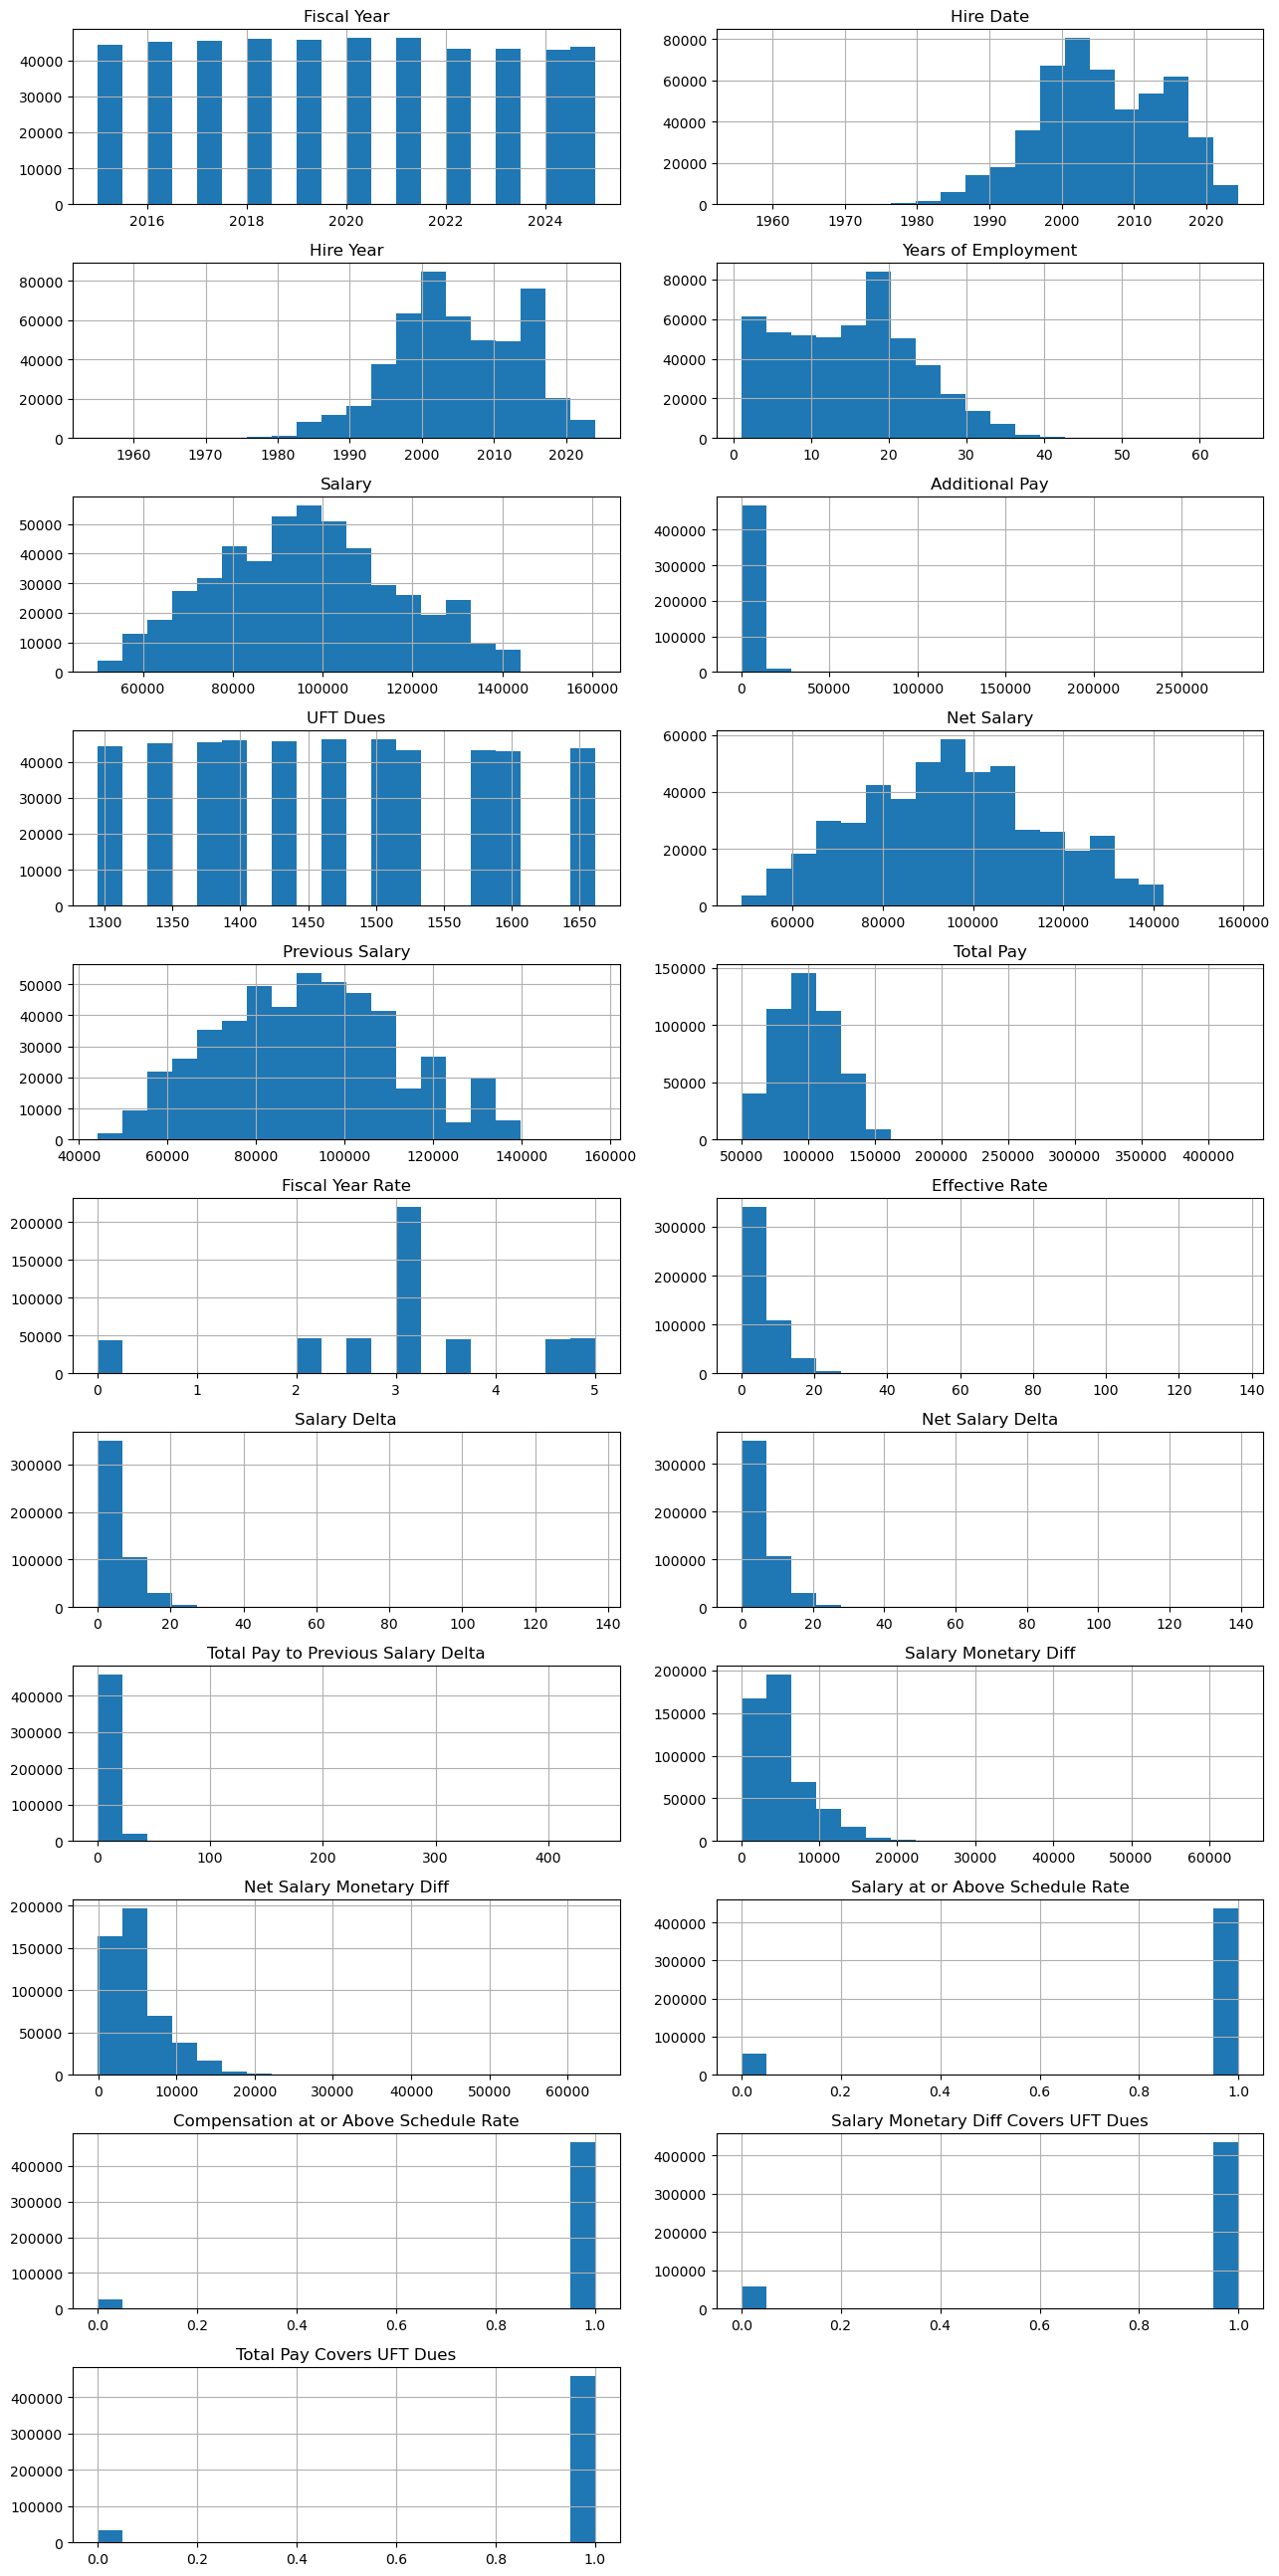

In [7]:
# Visualize the distributions of our numeric features
df.hist(figsize=(13,26), ec='black', layout=(11, 2), bins=20)
plt.tight_layout()
plt.show()

### Initial Findings
- Each record represents a teacher's salary for a given **fiscal year** (July 1 - June 30).
- There are ~44,000 full-time teachers employed in NYC annually, totaling ~492,000 salary records from FY2015-FY2025.
- Most teachers were hired in the early 2000s with a median tenure of 15 years.
    - 75% of teachers have at least 8 years of tenure.
    - Bimodal hire distribution: peaks in the early 2000s and mid-2010s.
- Most teacher salaries range from $80K to $100K.
    - Teachers most commonly earn $0 in additional pay.
- Year over year, most teachers:
    - Receive a salary increase (measured by `Salary Delta`).
    - See a $0-$5K monetary increase in salary.
    - Earn a 0-5% salary increase, typically at or above the UFT schedule rate.
- UFT union dues increase each year but are consistently covered by salary increases for most teachers.

## Exploratory Data Analysis

The UFT negotiated three contract periods during this timeframe, each with different annual salary increase rates:

| Contract Period | Fiscal Year Rates |
|---|---|
| **2009-2018** | 1%, 3%, 3.5%, 4.5%, 5% |
| **2019-2021** | 2%, 2.5%, 3% |
| **2022-2027** | 0%, 3%, 3%, 3.25%, 3.5% |

### Key Questions
- How do actual salary increases compare to these negotiated rates?
- Do newer teachers (0-5 years) experience different salary growth than tenured teachers (6+)?
- Do the negotiated raises offset the cost of UFT union dues?

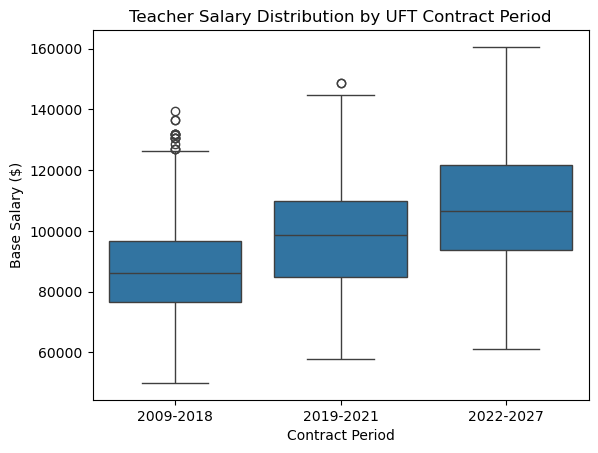

In [8]:
ax = sns.boxplot(data=df, y='Salary', x='Contract Period')
ax.set_title('Teacher Salary Distribution by UFT Contract Period')
ax.set_ylabel('Base Salary ($)')
plt.show()

### Is the Union Paying for Itself?

The chart below shows the **net annual compensation gain** per teacher: their salary increase plus additional pay, minus UFT union dues. A positive value means the teacher came out ahead after paying dues. Note that 6+ year teachers may also receive lump sum settlements or retroactive backpay that appears in Additional Pay.

In [ ]:
ax = sns.boxplot(data=df,
            x=df['Contract Period'],
            y=df['Additional Pay']+df['Salary Monetary Diff']-df['UFT Dues'],
            showfliers=False)
ax.set_title('Net Annual Compensation Gain by Contract Period')
ax.set_ylabel('Additional Pay + Salary Increase - UFT Dues ($)')
plt.tight_layout()
plt.savefig('./visuals/net-compensation-gain-by-contract.png', dpi=150, bbox_inches='tight')
plt.show()

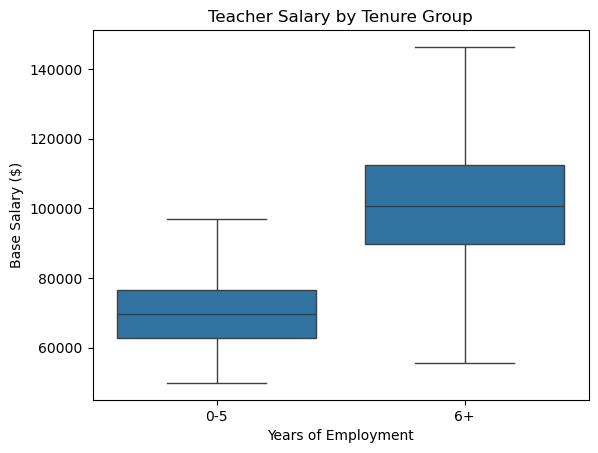

In [10]:
ax = sns.boxplot(data=df,
            x='Employment Category',
            y='Salary',
            showfliers=False)
ax.set_title('Teacher Salary by Tenure Group')
ax.set_ylabel('Base Salary ($)')
ax.set_xlabel('Years of Employment')
plt.show()

### FY2022 vs FY2023: The Impact of a 0% Contract Year

FY2022 had a **0% scheduled salary increase** — the only year with no contractual raise. FY2023 resumed with a 3% increase. Comparing these two years shows how contract terms directly affect teachers, and how tenure group matters: newer teachers (0-5 years) are more likely to still receive step increases even in a 0% year.

In [11]:
df_2022 = df[(df['Fiscal Year']==2022)]
df_2023 = df[(df['Fiscal Year']==2023)]
df_2022_no_change = df[(df['Fiscal Year']==2022)&(df['Delta Category']=='No Change')]
df_2023_no_change = df[(df['Fiscal Year']==2023)&(df['Delta Category']=='No Change')]

In [12]:
pd.crosstab(df_2022['Employment Category'], df_2022['Delta Category'], normalize='index').round(2)

Delta Category,No Change,Salary Increased
Employment Category,,
0-5,0.12,0.88
6+,0.56,0.44


In [13]:
pd.crosstab(df_2023['Employment Category'], df_2023['Delta Category'], normalize='index').round(2)

Delta Category,No Change,Salary Increased
Employment Category,,
0-5,0.11,0.89
6+,0.57,0.43


**Takeaway:** In FY2022 (0% contract year), **88% of newer teachers (0-5 years) still received a raise** thanks to step increases, while only **44% of tenured teachers (6+)** did. The UFT contract structure disproportionately protects newer teachers during flat years. However, tenured teachers may have received lump sum settlements or retroactive backpay reflected in their Additional Pay rather than base salary.

### What Proportion of Teachers Receive Raises Each Year?

Not all teachers receive a salary increase every year. The following charts show the proportion of teachers who received raises and the proportion whose total compensation met or exceeded the UFT schedule rate.

In [14]:
df_delta_bar = df.groupby('Fiscal Year')['Delta Category']\
                 .value_counts(normalize=True)\
                 .round(2).reset_index()

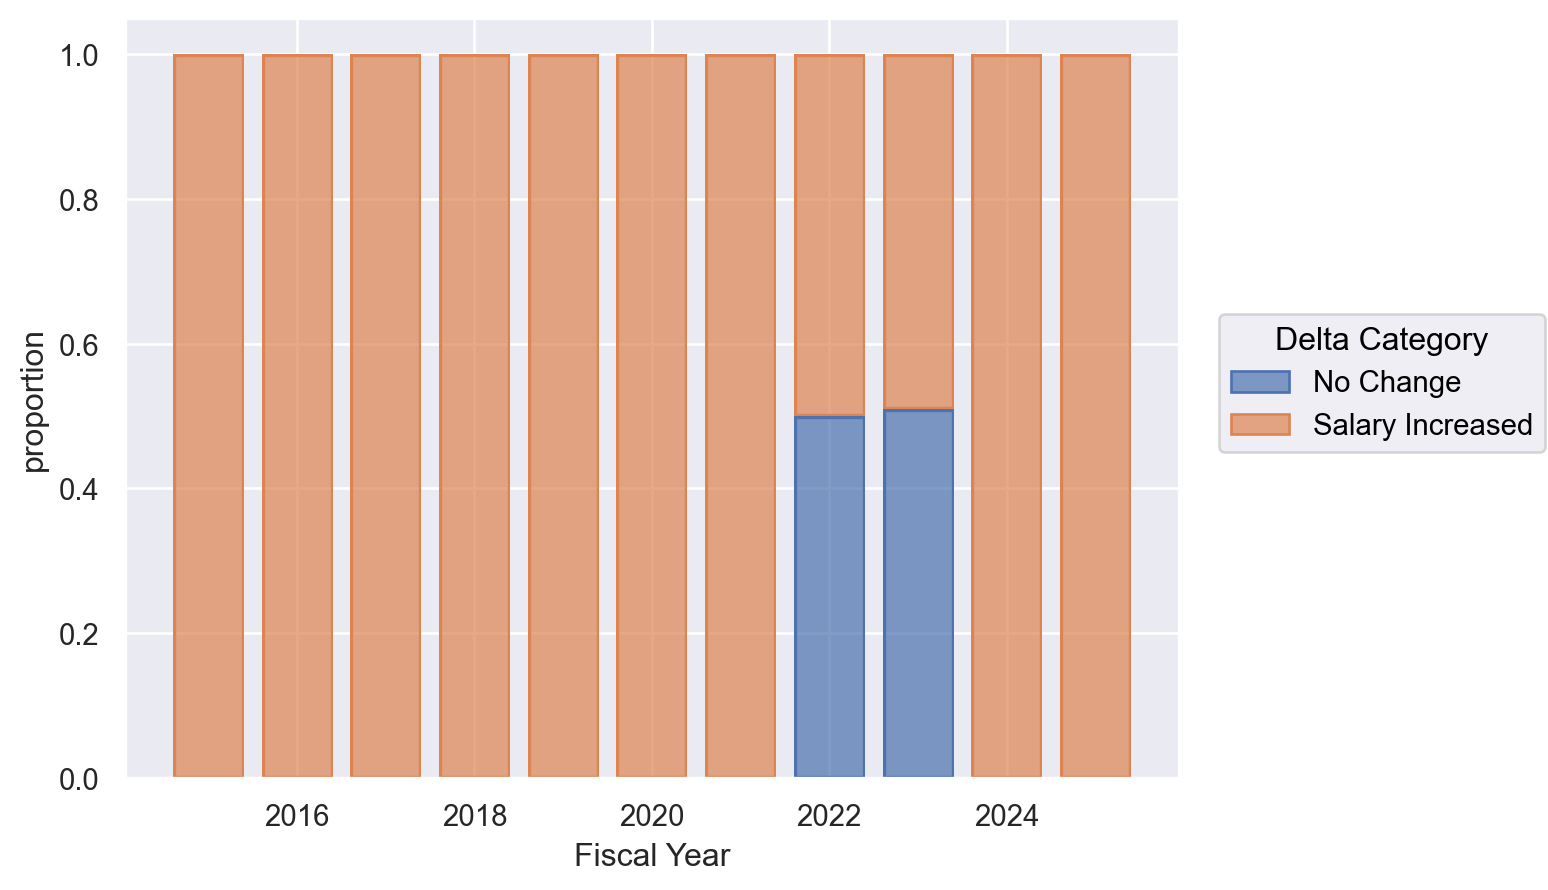

In [15]:
(
    so.Plot(data=df_delta_bar, x='Fiscal Year', y='proportion', color='Delta Category')
    .add(so.Bar(), so.Stack())
)

In [16]:
df_comp_bar = df.groupby('Fiscal Year')['Compensation at or Above Schedule Rate']\
                .value_counts(normalize=True)\
                .round(2).reset_index()

In [17]:
df_comp_bar['Compensation at or Above Schedule Rate'] = (
    np.where(df_comp_bar['Compensation at or Above Schedule Rate']!=0,'At or Above','Below')
)

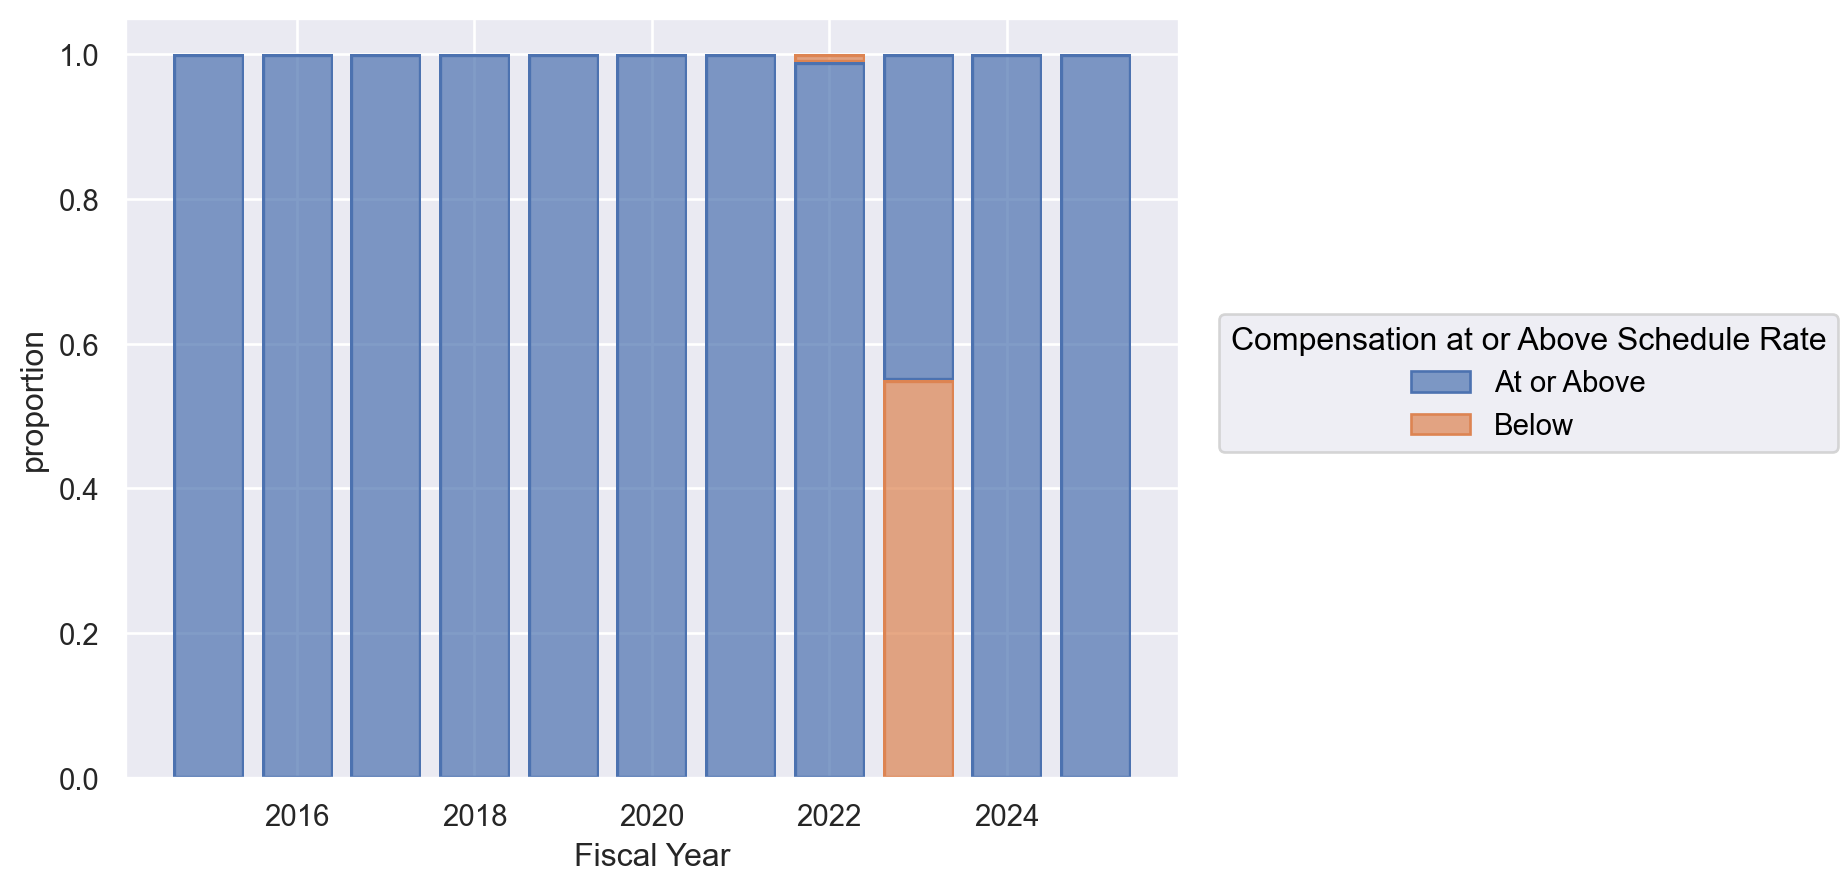

In [18]:
(
    so.Plot(data=df_comp_bar, x='Fiscal Year', y='proportion', color='Compensation at or Above Schedule Rate')
    .add(so.Bar(), so.Stack())
)

### Cumulative Salary Growth Over Time

How has total salary growth accumulated across contract periods? The bars show median cumulative salary increases by tenure group, while the black dashes show the cumulative UFT schedule rate. Bars above the dashes mean teachers are outpacing the negotiated rate.

In [19]:
df_rate_summary = df[df['Fiscal Year']>=2015].groupby(by=['Employment Category','Fiscal Year'])\
                    .agg({'Fiscal Year Rate': 'median',
                          'Effective Rate':'median',
                          'Salary Delta': 'median'
                          }).round(2)
df_rate_summary.columns = df_rate_summary.columns.get_level_values(0)
df_rate_summary = df_rate_summary.groupby(level=0).cumsum()
df_rate_summary = df_rate_summary.reset_index(col_level=-1)

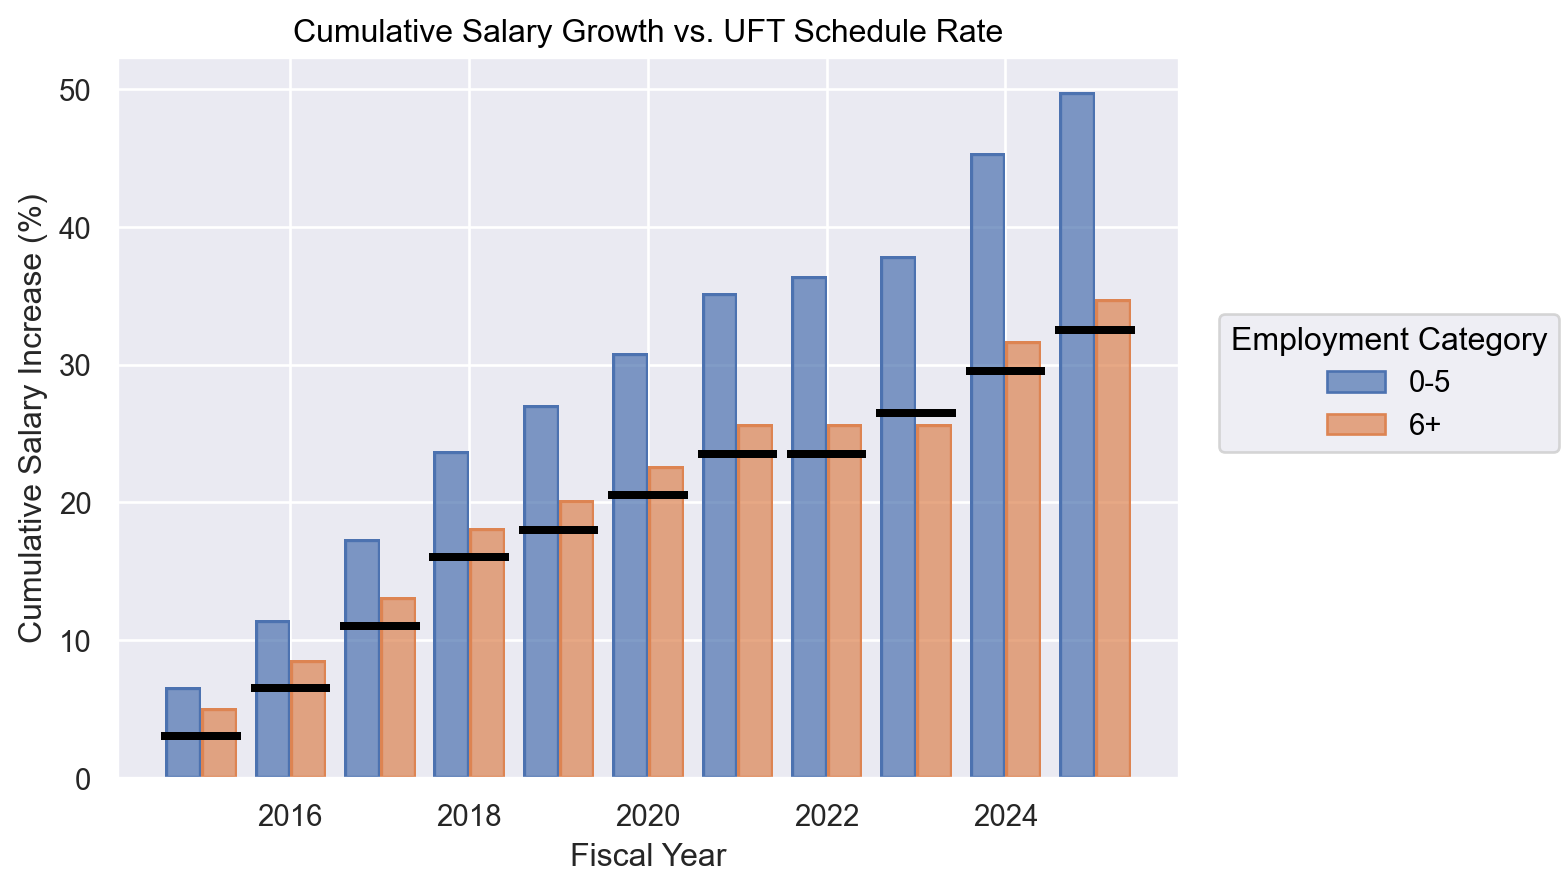

In [20]:
p1 = (
    so.Plot(data=df_rate_summary, x='Fiscal Year')
    .add(so.Bar(), so.Dodge(), y='Salary Delta', color='Employment Category')
    .add(so.Dash(linewidth=3, color='black'), y='Fiscal Year Rate')
    .label(x='Fiscal Year',
           y='Cumulative Salary Increase (%)',
           title='Cumulative Salary Growth vs. UFT Schedule Rate')
)
p1

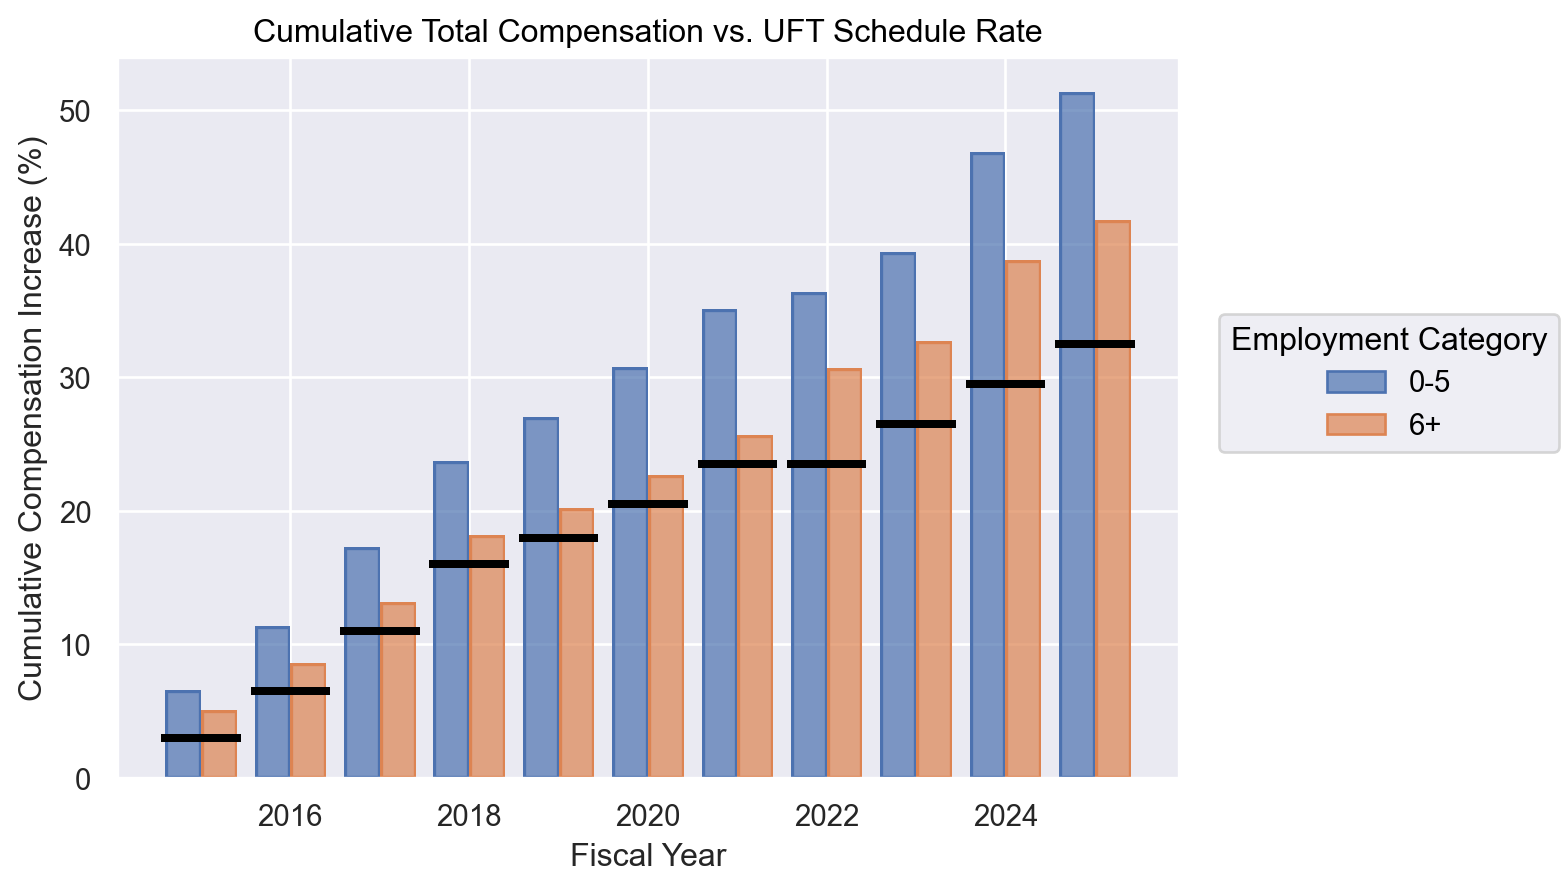

In [21]:
p2 = (
    so.Plot(data=df_rate_summary, x='Fiscal Year')
    .add(so.Bar(), so.Dodge(), y='Effective Rate', color='Employment Category')
    .add(so.Dash(linewidth=3, color='black'), y='Fiscal Year Rate')
    .label(x='Fiscal Year',
           y='Cumulative Compensation Increase (%)',
           title='Cumulative Total Compensation vs. UFT Schedule Rate')
)
p2

### Year-over-Year Salary Growth

While cumulative growth shows the full picture, year-over-year comparisons reveal how each individual contract year affected teachers. The black dashes represent the UFT-negotiated schedule rate for that year.

In [22]:
df_rate_summary_yoy = df[df['Fiscal Year']>=2015].groupby(by=['Employment Category','Fiscal Year'])\
                    .agg({'Fiscal Year Rate': 'median',
                          'Effective Rate':'median',
                          'Salary Delta': 'median'
                          }).round(2)
df_rate_summary_yoy.columns = df_rate_summary_yoy.columns.get_level_values(0)
df_rate_summary_yoy = df_rate_summary_yoy.reset_index(col_level=-1)

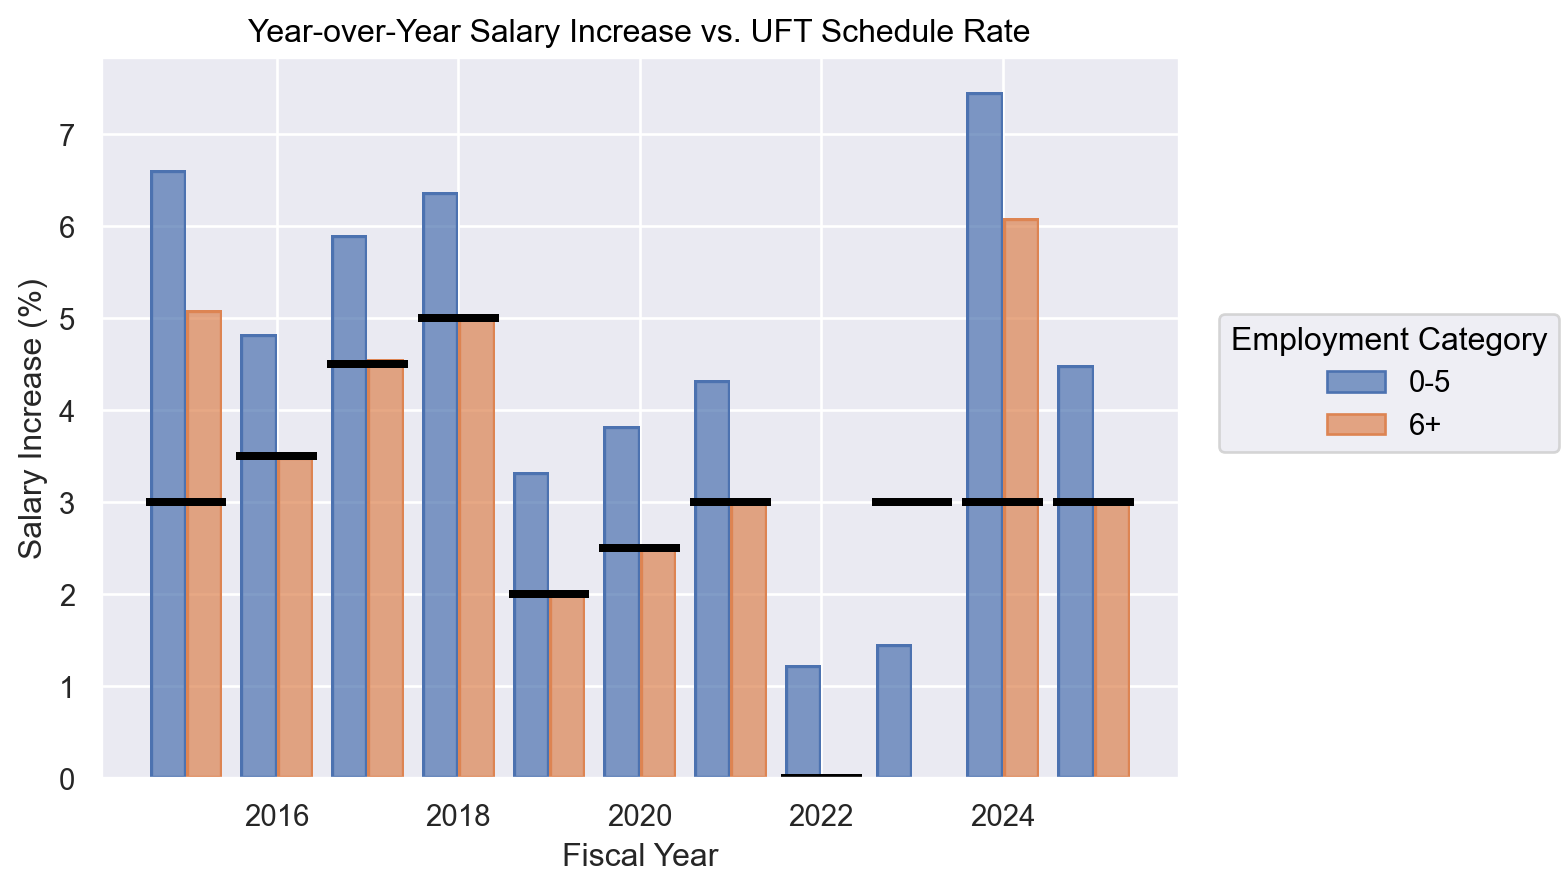

In [23]:
p3 = (
    so.Plot(data=df_rate_summary_yoy, x='Fiscal Year')
    .add(so.Bar(), so.Dodge(), y='Salary Delta', color='Employment Category')
    .add(so.Dash(linewidth=3, color='black'), y='Fiscal Year Rate')
    .label(x='Fiscal Year',
           y='Salary Increase (%)',
           title='Year-over-Year Salary Increase vs. UFT Schedule Rate')
)
p3

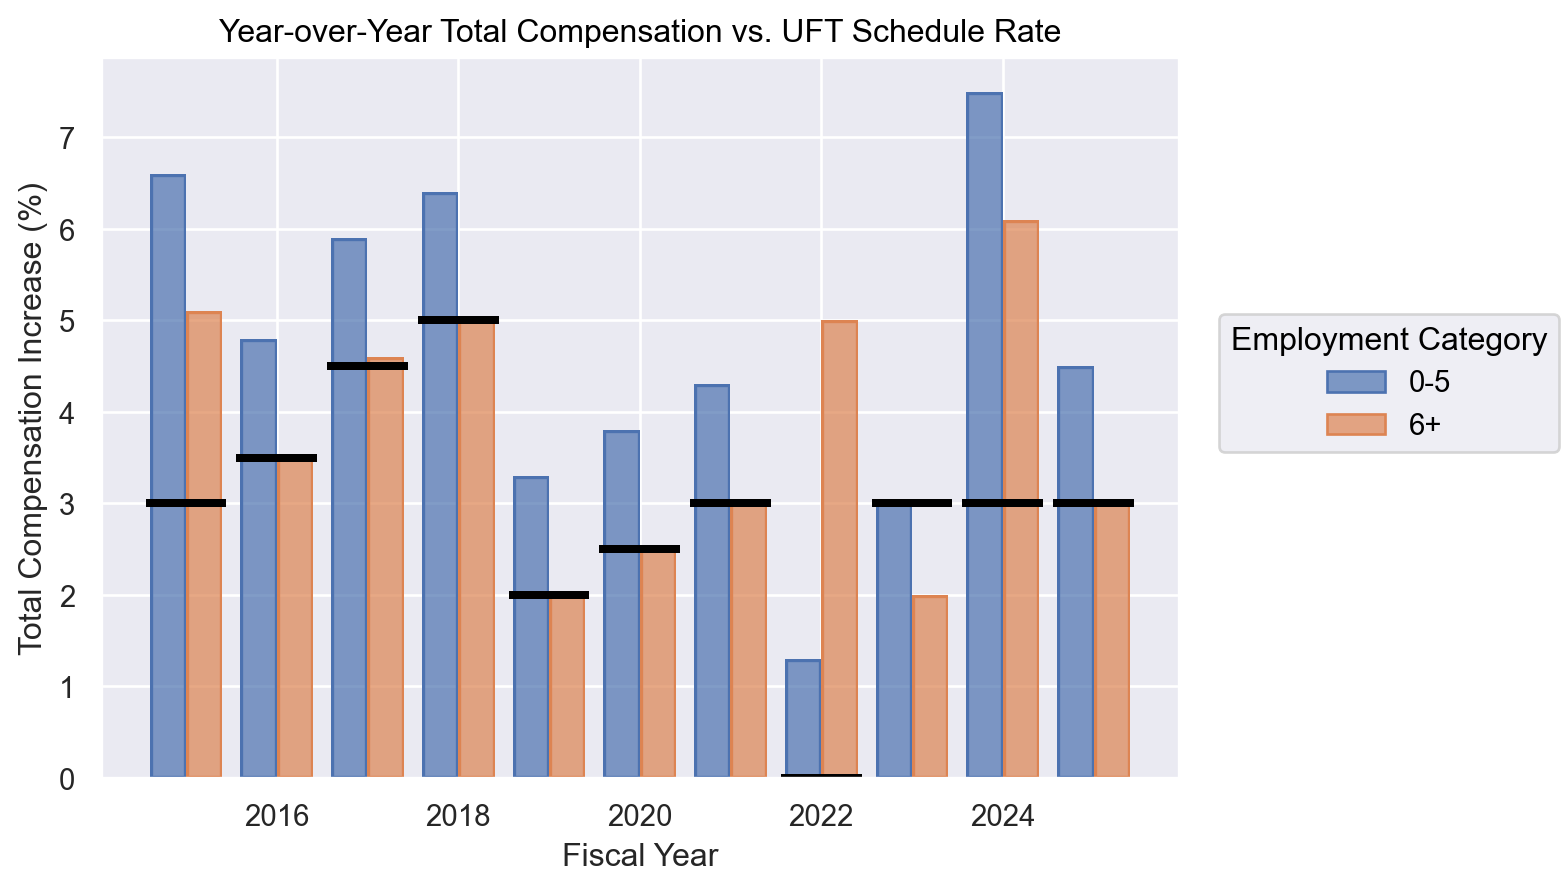

In [24]:
p4 = (
    so.Plot(data=df_rate_summary_yoy, x='Fiscal Year')
    .add(so.Bar(), so.Dodge(), y='Effective Rate', color='Employment Category')
    .add(so.Dash(linewidth=3, color='black'), y='Fiscal Year Rate')
    .label(x='Fiscal Year',
           y='Total Compensation Increase (%)',
           title='Year-over-Year Total Compensation vs. UFT Schedule Rate')
)
p4

## Conclusion

This analysis of ~492,000 teacher salary records across fiscal years 2015-2025 reveals that **UFT salary negotiations consistently deliver value to NYC teachers**, though the benefits are distributed unevenly:

1. **Union dues pay for themselves — when teachers receive a raise.** In years with scheduled increases, the median salary increase ($2,300-$7,500) far exceeds annual UFT dues ($1,295-$1,661). However, in FY2022 (0% year) and FY2023, the median salary increase was $0 because the majority of tenured teachers saw no base salary change.

2. **New teachers benefit the most.** Teachers with 0-5 years of experience receive larger percentage increases than tenured peers, driven by step increases on the salary schedule. Even in the 0% contract year, 88% of newer teachers still received a raise vs. only 44% of tenured teachers. This means early-career teachers can reach $100K in base salary faster under the current contract.

3. **Additional Pay bridges the gap for tenured teachers.** When base salary doesn't increase, Additional Pay — including lump sum settlements and retroactive backpay — often compensates. This is why the Effective Rate (total compensation change) consistently outpaces the Salary Delta (base salary change alone) in the cumulative charts.

4. **The 2022-2027 contract recovered from a flat year.** After a 0% increase in FY2022, the current contract delivers consistent 3%+ annual raises, and cumulative compensation growth has outpaced the schedule rate when including additional pay.

### For Teachers
- Compare your `Salary Delta` to the `Fiscal Year Rate` for your contract year to see if you're keeping pace.
- If your salary didn't increase, check whether your `Total Pay` (salary + additional pay) still grew — additional pay often compensates for flat salary years.
- Consider advancing your credentials (Master's degree, additional credits) to move up the salary schedule faster.

### Data Source
[NYC Citywide Payroll Data (Fiscal Year)](https://data.cityofnewyork.us/City-Government/Citywide-Payroll-Data-Fiscal-Year-/k397-673e) via NYC Open Data.